# Tutorial 3.2: Evading ML-based IDS using GANs

![Status](https://img.shields.io/static/v1.svg?label=Status&message=Under_Construction&color=orange)


**Open notebook on:** 
[![View filled on Github](https://img.shields.io/static/v1.svg?logo=github&label=Repo&message=View%20On%20Github&color=lightgrey)](https://github.com/clandolt/mlcysec_notebooks/blob/main/source/tutorial_notebooks/tutorial3_1_gan_getting_started/tutorial3_1_gan_getting_started.ipynb)
[![Open filled In Collab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/clandolt/mlcysec_notebooks/blob/main/source/tutorial_notebooks/tutorial3_1_gan_getting_started/tutorial3_1_gan_getting_started.ipynb)   
**Author:** Christoph R. Landolt


As shown in Tutorial 1 and 2 have Machine Learning-based Intrusion Detection Systems (ML-IDS) significantly improved the detection of cyberattacks in modern networks. However, as defenders adopt ML models, adversaries have also begun leveraging machine learning, e.g. **Generative Adversarial Networks (GANs)**, to craft adversarial network traffic that can evade these systems while maintaining the appearance of legitimate data.

This tutorial demonstrates how adversarial techniques can be used to evade a trained ML-based IDS using the CICIDS-2017 dataset, based on the approach presented in [Zolbayar et al., “Evading Machine Learning-Based Network Intrusion Detection Systems with GANs,” 2021](https://doi.org/10.1002/9781119723950.ch17).

## Tutorial Objectives
By the end of this tutorial, you will be able to:
- Understand how adversarial machine learning applies to cybersecurity and network intrusion detection.
- Implement a simple GAN-based adversarial attack to fool a pre-trained ML-based IDS.
- Discuss defensive strategies against adversarial attacks in IDS.

## ML-Based IDS and Their Limitations

ML-based Intrusion Detection Systems (IDS) rely on classification (Tutorial 1) or anomaly detection (Tutorial 2) to separate benign from malicious network traffic. While powerful, these models have two central weaknesses that can be exploited by attackers.

1.  **Data Scarcity and Class Imbalance.** Training datasets are often heavily skewed towards benign traffic, which impacts models in different ways. For **supervised classifiers**, the lack of labeled examples means they have no way to learn about "zero-day" attacks that were unknown when the data was collected. In contrast, **anomaly detectors**, while designed to find novelty, can still miss sophisticated attacks that are crafted to appear statistically similar to benign traffic.

2.  **Adversarial Vulnerability.** Attackers can actively fool ML models by crafting malicious inputs that are designed to be misclassified as benign. This field of study is known as **Adversarial Machine Learning**. In the network domain, an adversary might slightly modify packet- or flow-level features (e.g., duration, byte/packet counts) so that malicious traffic appears statistically normal to a trained IDS. These manipulated inputs are called **adversarial examples**.

    **Example:** An attacker slightly changes packet counts or the average packet size of their traffic so that it falls within the “normal” range learned by the IDS, causing a misclassification.

    This is a critical weakness even for the anomaly-based models from Tutorial 2 (Isolation Forest, One-Class SVM, etc.). While these models strengthen detection compared to classic signature-based approaches, attackers can still probe and exploit their learned decision boundaries.

This raises a fundamental question:

> How robust are ML-based intrusion detection systems to intelligent adversaries who deliberately craft network traffic to deceive them?

### Defining Adversarial Examples
An **adversarial example** is an input to a machine learning model that has been intentionally modified in a minimal and domain-feasible way so the model makes an incorrect prediction.

Formally, let $f:\mathbb{R}^n\to\mathbb{R}^m$ be a trained classifier and let $\mathbf{x}\in\mathbb{R}^n$ be an input with true label $y^\star$ and predicted label $\hat y(\mathbf{x})=\arg\max_j f(\mathbf{x})_j$ (i.e., the class with the highest output score). An adversary seeks a perturbation $\Delta\mathbf{x}$ that is small under some norm while ensuring the perturbed input remains valid for the domain and that the model predicts a different target class $t\neq \hat y(\mathbf{x})$. A common targeted formulation is

$$\begin{align}
\min_{\Delta\mathbf{x}}\quad & c\;\|\Delta\mathbf{x}\|_{p} + \mathcal{L}\big(f(\mathbf{x}+\Delta\mathbf{x}),\,t\big) \notag \\
\text{s.t.}\quad & \mathbf{x} + \Delta\mathbf{x} \in \mathcal{C} \notag
\end{align}$$

where $\mathcal{C}$ denotes domain-specific validity constraints (e.g., integer packet counts, protocol-consistent headers, non-negativity), and $\mathcal{L}$ is an attack loss. Common norms used to measure perturbation size include:
- $\ell_0$: sparsity of modified features,
- $\ell_2$: overall magnitude,
- $\ell_\infty$: maximum per-feature change.

For *untargeted* attacks the loss $\mathcal{L}$ is replaced or modified to encourage any label different from the original prediction.

**In essence:** an adversarial example is a *malicious input disguised as normal* by making small, carefully chosen modifications that exploit the model’s decision boundary.

#### Intuition
ML models, especially complex ones, learn decision surfaces where small, carefully chosen perturbations can move an input across the boundary. In networking, this translates to:
- slight changes in packet timing or sizes,
- minor tweaks to flow statistics,
- adding or modifying benign-looking header fields,

that can cause an IDS to label malicious traffic as **benign**, producing an *evasion attack*.

#### Types of Adversarial Attacks

Attacks are typically categorized by the level of knowledge the adversary has about the target model.

<table class="tutorial-table" border="1" style="width:100%; border-collapse: collapse;">
  <thead>
    <tr>
      <th>Attack Type</th>
      <th>Knowledge Assumed by the Attacker</th>
      <th>Description</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <td><b>White-box</b></td>
      <td>Full access to model parameters, architecture, and gradients.</td>
      <td>Attacker can compute exact perturbations to fool the model. Most powerful but least realistic.</td>
    </tr>
    <tr>
      <td><b>Black-box</b></td>
      <td>No internal model knowledge; can only query inputs and observe outputs.</td>
      <td>Attacker approximates the target model by training a substitute, then crafts attacks against it. Highly practical.</td>
    </tr>
    <tr>
      <td><b>Gray-box</b></td>
      <td>Partial knowledge (e.g., model type or training data distribution).</td>
      <td>A realistic scenario between the two extremes.</td>
    </tr>
  </tbody>
</table>

GAN-based attacks typically operate under a **black-box threat model**, where the attacker has no access to the internal parameters of the target IDS. Instead, they train a **generator–discriminator framework** that learns to mimic the IDS's decision boundary. Once trained, the generator can craft adversarial traffic samples that mimic benign traffic yet successfully evade detection.

### Generative Adversarial Networks (GANs)

#### Core Concept

Generative Adversarial Networks (GANs), introduced by [Goodfellow et al. (2014)](https://arxiv.org/abs/1406.2661), consist of two competing neural networks: a **generator (G)** and a **discriminator (D)**. The generator's goal is to create synthetic data, while the discriminator's goal is to distinguish real data from the generator's fakes. Through this adversarial process, both networks improve, with the generator learning to produce increasingly realistic samples that can fool the discriminator.

GANs are increasingly applied in adversarial intrusion detection research for two key reasons:

1.  The adversarial training dynamic encourages the generator to produce **plausible and realistic modifications** to attack traffic, rather than just random noise.
2.  Their proven success in creating powerful evasion attacks in the image domain has inspired the **adaptation of GANs for network security**.

#### Mathematical Framework

The training process is a two-player minimax game defined by the objective function:

$$
\min_G \max_D V(D, G) = \mathbb{E}_{x \sim p_{\text{data}}(x)}[\log D(x)] + \mathbb{E}_{z \sim p_z(z)}[\log(1 - D(G(z)))]
$$

Let's break this down:

*   The **Discriminator (D)** wants to maximize this function. It does this by:
    1.  Maximizing the first term, $\mathbb{E}_{x \sim p_{\text{data}}(x)}[\log D(x)]$. This means it wants its output $D(x)$ to be close to 1 (high probability) for real samples $x$.
    2.  Maximizing the second term, $\mathbb{E}_{z \sim p_z(z)}[\log(1 - D(G(z)))]$. This means it wants its output $D(G(z))$ to be close to 0 (low probability) for fake samples $G(z)$.

*   The **Generator (G)** wants to minimize this function by making the second term as small as possible. It tries to make $D(G(z))$ close to 1, fooling the discriminator into thinking its fake samples are real.

Training continues until the generator produces samples that are so realistic that the discriminator is no better than random chance at telling them apart (i.e., $D(x) \approx 0.5$ for all inputs). At this equilibrium, the generator has successfully learned the underlying distribution of the real data.

#### GAN-Based Adversarial Attacks for IDS

In the context of intrusion detection, **GAN-based adversarial attacks** generate **malicious traffic designed to evade machine learning–based IDS models**. Two major variants have been applied to this problem: **IDSGAN** and **AdvGAN**.
Although both leverage the GAN framework, they differ fundamentally in how the generator alters input data and how they enforce realism or domain constraints.

### IDSGAN

[**IDSGAN** (Lin et al., 2018)](https://arxiv.org/abs/1809.02077) was designed for the network intrusion detection domain to generate adversarial traffic that can evade a **black-box** target model. As illustrated in the diagram, the framework is a dynamic system involving three key components.

-   **Generator (G):** Takes the mutable part of a malicious traffic sample ($\vec{x_M}$) and perturbs it to create new "crafted features" ($\vec{x_C}$). Its goal is to produce a full adversarial sample, $\vec{x_A}$, that preserves the attack's function while being misclassified as benign.
-   **Black-Box NIDS (B):** This is the pre-trained, fixed **target model**. It acts as an "oracle," providing classification labels for both benign traffic ($\vec{x_B}$) and adversarial traffic ($\vec{x_A}$). These labels serve as the ground truth for training the Discriminator.
-   **Discriminator (D):** Serves as a **differentiable proxy** for the target NIDS. It learns to **imitate the behavior of the Black-Box NIDS** by taking traffic data ($\vec{x_B}$, $\vec{x_A}$) and the corresponding predicted labels from the NIDS as input. By mimicking the target, it provides the necessary gradients to train the Generator.

**Feature Partitioning**

To maintain the validity of the attack, an original malicious traffic sample, $\vec{x_{mal}}$, is separated into two vectors:

-   **Immutable Features ($\vec{x_I}$):** A vector of features essential to the attack's success. These are passed through unmodified.
-   **Mutable Features ($\vec{x_M}$):** A vector of features that can be altered without breaking the attack’s core function. These are fed into the Generator.

The Generator's output, $\vec{x_C}$, is combined with $\vec{x_I}$ to form the final adversarial sample: $\vec{x_A} = \begin{bmatrix} \vec{x_I} \\ \vec{x_C} \end{bmatrix}$.

**Objective Functions (Based on Wasserstein GAN)**

The loss functions are designed to train the Discriminator to mimic the NIDS and the Generator to fool this mimic, using clearer notation for each traffic type.

**Generator Loss ($\mathcal{L}_G$)**
The Generator is trained to create adversarial samples, $\vec{x_A}$, that the Discriminator classifies as 'Normal'. Let $G(\vec{x_{mal}})$ represent the full process of generating $\vec{x_A}$ from an original malicious sample $\vec{x_{mal}}$.
$$
\mathcal{L}_G = \mathbb{E}_{\vec{x_{mal}}} [D(G(\vec{x_{mal}}))]
$$
-   The Generator's goal is to **minimize** this loss. It adjusts its weights via the gradient-based training loop to produce adversarial traffic that receives a low score from the Discriminator $D$.

**Discriminator Loss ($\mathcal{L}_D$)**
The Discriminator is trained to assign high scores to traffic the NIDS labels as 'Attack' ($\vec{x_A}$) and low scores to traffic the NIDS labels as 'Normal' ($\vec{x_B}$).
$$
\mathcal{L}_D = \mathbb{E}_{\vec{x_B}} [D(\vec{x_B})] - \mathbb{E}_{\vec{x_A}} [D(\vec{x_A})]
$$
-   The Discriminator's goal is to **maximize** this loss by learning to replicate the classification boundaries of the Black-Box NIDS.

<img src="./IDSGAN.jpg" alt="IDSGAN" width="800"/>

### AdvGAN

[**AdvGAN** (Xiao et al., 2018)](https://arxiv.org/abs/1801.02610), initially proposed for **image classification**, is a framework that learns to generate adversarial perturbations. The architecture, shown in the diagram, uses a Generator, a Discriminator, and a fixed Target model to achieve its goals.

**Architectural Components**

-   **Generator (G):** The Generator learns to produce a subtle **perturbation vector**, $\Delta \vec{x}$. This perturbation is then added to the original input vector $\vec{x}$ to create the final adversarial example: $\vec{x'} = \vec{x} + \Delta \vec{x}$.
-   **Discriminator (D):** This is a standard GAN discriminator whose job is to enforce **realism**. It is trained to distinguish between a *real example* ($\vec{x}$) and the *adversarial example* ($\vec{x'}$). As shown in the diagram, its feedback results in the **Realism Loss**.
-   **Target Intrusion Detection System (IDS):** This is the **fixed, pre-trained victim model** that the attack aims to fool. It is not updated during training. Its output is used to calculate the **Adversarial Loss**, which guides the Generator to create effective, misclassification-inducing perturbations.

**Loss Function**

As visualized in the diagram, AdvGAN's generator loss is a combination of multiple components that are used to update the Generator via a feedback loop. The complete loss function creates effective yet realistic perturbations:

$$
\mathcal{L}_G = \mathcal{L}_{\text{adv}} + \lambda \cdot \mathcal{L}_{\text{pert}} + \gamma \cdot \mathcal{L}_{\text{GAN}}
$$

-   **$\mathcal{L}_{\text{adv}}$ (Adversarial Loss):** This loss comes from the **Target IDS**. It penalizes the Generator if the target model correctly classifies the adversarial example $\vec{x'}$. This drives the generator to find a perturbation that causes a misclassification.
-   **$\mathcal{L}_{\text{GAN}}$ (Realism Loss):** This loss is provided by the **Discriminator**. It penalizes the Generator if the Discriminator can tell that the adversarial example $\vec{x'}$ is "fake" (i.e., not from the original data distribution). This ensures the perturbation is realistic.
-   **$\mathcal{L}_{\text{pert}}$ (Perturbation Penalty):** Although not explicitly drawn as a separate box, this loss (typically an L2-norm, $ ||\Delta \vec{x}||_2 $) directly penalizes the size of the perturbation created by the Generator, ensuring the change is subtle.

When adapted to IDS tasks, this structure allows for precise attacks that can cause misclassification while ensuring the resulting traffic records remain valid and interpretable.

<img src="./AdvGAN.jpg" alt="AdvGAN" width="800"/>

### Comparison: IDSGAN vs. AdvGAN

The two approaches represent different philosophies in generating adversarial network traffic.

<table class="tutorial-table" border="1" style="width:100%; border-collapse: collapse;">
  <thead>
    <tr>
      <th>Aspect</th>
      <th>IDSGAN</th>
      <th>AdvGAN</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <td><b>Domain</b></td>
      <td>Network intrusion traffic</td>
      <td>Images (adaptable to tabular/network data)</td>
    </tr>
    <tr>
      <td><b>Perturbation Strategy</b></td>
      <td>Replaces a modifiable subset of features <i>x<sub>N</sub></i></td>
      <td>Learns an additive perturbation Δx to apply to the full input <i>x</i></td>
    </tr>
    <tr>
      <td><b>Core Mechanism</b></td>
      <td>Generates a full modified sample</td>
      <td>Generates only the perturbation vector</td>
    </tr>
    <tr>
      <td><b>Constraint Handling</b></td>
      <td>Manual feature partitioning (pre-generation)</td>
      <td>Post-generation masking and projection to enforce validity</td>
    </tr>
    <tr>
      <td><b>Threat Model</b></td>
      <td>Black-box (discriminator mimics IDS)</td>
      <td>Typically white-box; adaptable to black-box via transferability</td>
    </tr>
    <tr>
      <td><b>Strengths</b></td>
      <td>Domain-aware; interpretable; network-specific</td>
      <td>Highly effective; generalizable; perturbation-focused</td>
    </tr>
    <tr>
      <td><b>Weaknesses</b></td>
      <td>Depends heavily on feature engineering; can be brittle</td>
      <td>Requires careful handling of domain constraints for non-image data</td>
    </tr>
  </tbody>
</table>

### Enforcing Domain Constraints

Unlike continuous image data, **network traffic data** is structured and discrete. To craft realistic adversarial examples, we must enforce domain rules during generator training. These rules fall into two families:

1.  Enforcement of constraints on **intrinsic features** (structural constraints).
2.  Enforcement of constraints on **valid ranges** (attacker capability constraints).

#### 1. Constraints on Intrinsic Features

Some features must never be changed because they encode the attack identity or categorical information that cannot be meaningfully perturbed:

- **Attack-dependent invariants**: Certain features are fixed for a given attack type and must remain constant.
- **Protocol-dependent zeros and enums**: A protocol implies that a subset of features is always zero or only takes a restricted set of values (e.g., TCP flags, services).
- **One-hot / categorical features**: One-hot encoded categorical fields must not be perturbed (or must be projected back to a valid one-hot vector).

To enforce these rules, we mask the generator's output at every training iteration. Let the generator produce a perturbation vector
$$
\vec{\Delta x} = (\Delta x_1, \ldots, \Delta x_n)^\top,
$$
and let the binary mask vector be
$$
\vec{m} = (m_1, \ldots, m_n)^\top,\qquad m_k \in\{0,1\},
$$
where $m_k=1$ indicates the $k$-th feature is allowed to change, and $m_k=0$ indicates it must remain fixed.

The masked perturbation is the Hadamard product:
$$
\vec{\Delta x}^{\,\text{masked}} = \vec{\Delta x}\circ\vec{m},
$$
which elementwise yields $(\vec{\Delta x}\circ\vec{m})_k = m_k\,\Delta x_k$. Finally, the generator produces the candidate adversarial sample by applying the masked perturbation to the original instance $x$:
$$
x' = x + \vec{\Delta x}^{\,\text{masked}}.
$$

**Implementation notes:**
- Build $\vec{m}$ once from rules (attack type, protocol, one-hot indices). The effect is shown below:

| index | 1 | 2 | 3 | 4 | 5 | ... | n |
|---:|---:|---:|---:|---:|---:|---:|---:|
| $\Delta x$ | $\Delta x_1$ | $\Delta x_2$ | $\Delta x_3$ | $\Delta x_4$ | $\Delta x_5$ | ... | $\Delta x_n$ |
| $m$ | 1 | 0 | 1 | 0 | 1 | ... | 1 |
| masked | $\Delta x_1$ | 0 | $\Delta x_3$ | 0 | $\Delta x_5$ | ... | $\Delta x_n$ |

- For one-hot/categorical features, either set the corresponding $m_k=0$ (do not perturb) or allow a special projection step that maps the perturbed vector back to the nearest valid category.
- Masking is applied inside the generator function or immediately after its output, before any clipping or classifier evaluation.

#### 2. Constraints on Valid Ranges (Attacker Capability)

Even when a feature is mutable, its value must remain within a realistic, class-specific range. For each attack class (e.g., DoS, Probe, Benign) we compute per-feature valid intervals from the training data:
- For class `DoS` and feature $x_i$: $[d_i^{\min}, d_i^{\max}]$
- For class `Probe`: $[p_i^{\min}, p_i^{\max}]$
- For class `Benign`: $[b_i^{\min}, b_i^{\max}]$

<img src="./deception_enforcement.jpg" alt="deception_enforcement" width="600"/>

When applying a masked perturbation, we clip each feature to its class-specific valid range. Let $R_i$ denote the valid interval for feature $i$ for the current attack class; then the clipped adversarial value is:

$$
x'_i = \operatorname{clip}\big(x_i + m_i \,\Delta x_i,\; R_i^{\min},\; R_i^{\max}\big),
$$

where $\operatorname{clip}(v,a,b) = \min\{\,\max\{v,a\},\,b\}$. In vector form, this is:

$$
x' = \operatorname{clip}\big( x + (\vec{\Delta x}\circ\vec{m}),\; \vec{R}^{\min},\; \vec{R}^{\max} \big),
$$

where the clip is applied elementwise and $\vec{R}^{\min},\vec{R}^{\max}$ are the per-feature lower/upper bounds for the attack class.

**Practical procedure per training iteration:**
1.  Generator computes raw perturbation $\vec{\Delta x}$.
2.  Apply mask: $\vec{\Delta x}^{\,\text{masked}} = \vec{\Delta x}\circ\vec{m}$.
3.  Form candidate sample: $\tilde x = x + \vec{\Delta x}^{\,\text{masked}}$.
4.  Clip to valid ranges per feature/class: $x' = \operatorname{clip}(\tilde x,\; \vec{R}^{\min},\; \vec{R}^{\max})$.
5.  If any categorical features were allowed to change, project them back to the nearest valid category / one-hot vector.
6.  Feed $x'$ to the discriminator and (if applicable) to the surrogate target classifier for adversarial loss.

**Why both constraints are necessary:**
- **Masking** prevents semantic corruption (keeps attack functionality intact and respects categorical structure).
- **Clipping** enforces attacker capability limits and prevents unrealistic values that would be trivially rejected by non-ML checks.

#### Notes on computing ranges:
- Compute per-class, per-feature minima and maxima from training data (or use percentiles like 1st/99th to reduce sensitivity to outliers).
- Optionally enforce integer rounding for count-like features after clipping.
- For features with known protocol rules (flags, port ranges), apply rule-based projection rather than raw data-driven clipping.

### Key Implications and Recommended Defenses

The success of these GAN-based attacks reveals several critical insights about ML-based security:

- GAN-generated adversarial samples can **severely degrade IDS detection accuracy**.
- Such attacks often **transfer across different models**, confirming their **black-box evasion** potential.
- The success of these methods highlights the **fragility of data-driven IDS boundaries**, which often rely on non-causal statistical correlations rather than a true understanding of threats.
- Under adaptive threats, even IDS models with high static accuracy can **fail catastrophically**.

This underscores the urgent need for more robust defense strategies, including:

- **Adversarial Training:** Augmenting training data with generated adversarial examples to make models more resilient.
- **Model Ensembles:** Combining diverse models to create a more complex and harder-to-evade decision boundary.
- **Input Sanitization:** Pre-processing pipelines to detect and reject or normalize anomalous-looking inputs before they reach the model.
- **Causal and Invariant Feature Engineering:** Designing features that are causally linked to malicious activity and invariant to the simple perturbations used in evasion attacks.


## Implementation: Evading an IDS with GANs

In this section, we will implement the concepts discussed above. The process is broken down into four main steps:
1. **Load and Prepare Data:** We will load the CICIDS-2017 dataset and prepare it for our models.
2. **Train Target IDS Model:** We will train a standard MLP classifier to act as our victim IDS.
3. **Train and Evaluate IDSGAN:** We will build and train an IDSGAN to conduct a black-box attack against our target IDS.
4. **Train and Evaluate AdvGAN:** We will then build and train an AdvGAN, which uses a different adversarial strategy, to attack the same IDS.

First, let's start with the necessary imports and setting up our environment to use a GPU if available.

In [8]:
# --- Basic Imports ---
import os
import pandas as pd
import numpy as np
from glob import glob
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import matplotlib.pyplot as plt

# --- PyTorch Imports ---
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader


# --- Configure Device (GPU or CPU) ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


### Step 1: Load and Explore the CICIDS-2017 Dataset
- Downloading the dataset from Kaggle (if not already available)
- Loading parquet files from multiple attack types
- Cleaning, merging, and preparing the final binary classification dataset (Benign vs Attack)


In [9]:
# Dataset parameters
FILE = "cicids2017.zip"
DIR = "cicids2017"
URL = "https://www.kaggle.com/api/v1/datasets/download/dhoogla/cicids2017"

# Download if not exists
if not os.path.isfile(FILE):
    print(f"📥 Downloading {FILE} from Kaggle...")
    !curl -L -o {FILE} {URL}
else:
    print(f"✅ {FILE} already exists, skipping download.")

# Unzip if not exists
if not os.path.isdir(DIR):
    print(f"📦 Unzipping {FILE}...")
    !unzip -q {FILE} -d {DIR}
else:
    print(f"✅ {DIR} already exists, skipping unzip.")

✅ cicids2017.zip already exists, skipping download.
✅ cicids2017 already exists, skipping unzip.


**Load and Merge Data Files:**
Load the CICIDS2017 parquet files by attack category and combine them into a single DataFrame.


In [10]:
import os
import pandas as pd
import numpy as np

# 🔍 Display available files (from local directory)
DATA_DIR = "./cicids2017"   # ← adjust this if your folder name/path differs

for dirname, _, filenames in os.walk(DATA_DIR):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# 📂 Load Parquet data files by attack type (local paths)
df_data_1 = pd.read_parquet(os.path.join(DATA_DIR, 'Benign-Monday-no-metadata.parquet'))
df_data_2 = pd.read_parquet(os.path.join(DATA_DIR, 'Bruteforce-Tuesday-no-metadata.parquet'))
df_data_3 = pd.read_parquet(os.path.join(DATA_DIR, 'Portscan-Friday-no-metadata.parquet'))
df_data_4 = pd.read_parquet(os.path.join(DATA_DIR, 'WebAttacks-Thursday-no-metadata.parquet'))
df_data_5 = pd.read_parquet(os.path.join(DATA_DIR, 'DoS-Wednesday-no-metadata.parquet'))
df_data_6 = pd.read_parquet(os.path.join(DATA_DIR, 'DDoS-Friday-no-metadata.parquet'))
df_data_7 = pd.read_parquet(os.path.join(DATA_DIR, 'Infiltration-Thursday-no-metadata.parquet'))
df_data_8 = pd.read_parquet(os.path.join(DATA_DIR, 'Botnet-Friday-no-metadata.parquet'))

# 🧩 Concatenate all data into a single DataFrame
df_data = pd.concat([
    df_data_1, df_data_2, df_data_3, df_data_4,
    df_data_5, df_data_6, df_data_7, df_data_8
], axis=0, ignore_index=True)

print("✅ Combined dataset shape:", df_data.shape)
df_data.head()


./cicids2017/DDoS-Friday-no-metadata.parquet
./cicids2017/Bruteforce-Tuesday-no-metadata.parquet
./cicids2017/Botnet-Friday-no-metadata.parquet
./cicids2017/DoS-Wednesday-no-metadata.parquet
./cicids2017/Benign-Monday-no-metadata.parquet
./cicids2017/Infiltration-Thursday-no-metadata.parquet
./cicids2017/Portscan-Friday-no-metadata.parquet
./cicids2017/WebAttacks-Thursday-no-metadata.parquet
✅ Combined dataset shape: (2313810, 78)


,Protocol,Flow Duration,Total Fwd Packets,Total Backward Packets,Fwd Packets Length Total,Bwd Packets Length Total,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,Fwd Seg Size Min,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,6,4,2,0,12,0,6,6,6.00000,0.000000,...,20,0.0,0.0,0,0,0.0,0.0,0,0,Benign
1,6,1,2,0,12,0,6,6,6.00000,0.000000,...,20,0.0,0.0,0,0,0.0,0.0,0,0,Benign
2,6,3,2,0,12,0,6,6,6.00000,0.000000,...,20,0.0,0.0,0,0,0.0,0.0,0,0,Benign
3,6,1,2,0,12,0,6,6,6.00000,0.000000,...,20,0.0,0.0,0,0,0.0,0.0,0,0,Benign
4,6,609,7,4,484,414,233,0,69.14286,111.967896,...,20,0.0,0.0,0,0,0.0,0.0,0,0,Benign


**Data Cleaning and Preprocessing:**
Handle missing values, infinite values, and duplicates.


In [11]:
# Select only numeric columns for model input
df_numeric = df_data.select_dtypes(include=[np.number])

# Identify infinite values
infinity_counts = np.isinf(df_numeric).sum()
print("♾️ Infinite value counts per column:\n", infinity_counts[infinity_counts > 0])

# Replace infinities with NaN and drop missing values
df_numeric = df_numeric.replace([np.inf, -np.inf], np.nan)
df_numeric = df_numeric.dropna()

# Drop duplicate rows
duplicates = df_data.duplicated().sum()
print(f"🧹 Found and removing {duplicates} duplicate rows...")
df_data = df_data.drop_duplicates()

print("✅ Cleaned dataset shape:", df_data.shape)


♾️ Infinite value counts per column:
 Series([], dtype: int64)
🧹 Found and removing 82004 duplicate rows...
✅ Cleaned dataset shape: (2231806, 78)


**Prepare Features and Labels:**
Convert multi-class attack labels into binary labels (0 = Benign, 1 = Attack).


In [12]:
# Separate features and labels
X = df_data.copy()
X = X.drop(columns='Label') 
y = df_data["Label"].copy()

# Binary encode labels: 0 = Benign, 1 = Attack
y_b = y.map({'Benign': 0}).fillna(1).astype(int).rename('Label')

# Create final binary-labeled DataFrame
df_binary = X.copy()
df_binary['Label'] = y_b

print("✅ Final dataset shape:", df_binary.shape)
print(df_binary['Label'].value_counts())


✅ Final dataset shape: (2231806, 78)
Label
0    1895314
1     336492
Name: count, dtype: int64


**Feature Scaling and Train-Test Split:**
Normalize features and prepare for model training and evaluation.


In [13]:
# Separate features and target
X = df_binary.drop(columns=['Label'])
y = df_binary['Label']

# Store feature names before scaling
feature_names = X.columns.tolist()

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train-test split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print("✅ Training samples:", len(X_train))
print("✅ Testing samples:", len(X_test))
print("📊 Attack ratio:", y.mean())


✅ Training samples: 1785444
✅ Testing samples: 446362
📊 Attack ratio: 0.1507711691786831


**Notes:**
- CICIDS-2017 provides realistic network flow features (e.g., duration, packet length, byte count, flow rate).
- We standardize all numeric features since GANs and neural networks require normalized inputs for stable training.

### Step 2: Train the Target IDS Model
Next, we will use the KDDNet PyTorch model from Tutorial 1 - Getting Started 4. This model will serve as our target IDS that we will attempt to evade.

#### 2.1 Define the KDDNet Model Architecture

In [14]:
class KDDNet(nn.Module):
    def __init__(self, input_dim):
        super(KDDNet, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(input_dim, 128), nn.Tanh(), nn.Dropout(0.3),
            nn.Linear(128, 64), nn.Tanh(), nn.Dropout(0.3),
            nn.Linear(64, 1), nn.Sigmoid()
        )
    def forward(self, x):
        return self.model(x)


#### 2.2 Prepare DataLoaders for Training

In [15]:
input_dim = X_train.shape[1]
train_dataset = TensorDataset(torch.tensor(X_train, dtype=torch.float32), torch.tensor(y_train, dtype=torch.float32).unsqueeze(1))
train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True)

#### 2.3 Train the Target IDS Model

In [16]:
print("\n🔥 Training the Target IDS Model (KDDNet)...")
target_ids_pytorch = KDDNet(input_dim).to(device)
criterion = nn.BCELoss()
optimizer = optim.Adam(target_ids_pytorch.parameters(), lr=0.001)

n_epochs = 10 # Train for a few epochs for demonstration
for epoch in range(n_epochs):
    target_ids_pytorch.train()
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        outputs = target_ids_pytorch(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()
    print(f"Epoch {epoch+1}/{n_epochs}, Loss: {loss.item():.4f}")



🔥 Training the Target IDS Model (KDDNet)...
Epoch 1/10, Loss: 0.0033
Epoch 2/10, Loss: 0.0246
Epoch 3/10, Loss: 0.0203
Epoch 4/10, Loss: 0.0262
Epoch 5/10, Loss: 0.0637
Epoch 6/10, Loss: 0.0405
Epoch 7/10, Loss: 0.0093
Epoch 8/10, Loss: 0.0076
Epoch 9/10, Loss: 0.0367
Epoch 10/10, Loss: 0.0209


#### 2.4 Evaluate the Baseline IDS Performance

In [18]:
print("\n📊 Baseline IDS Performance:")
target_ids_pytorch.eval()
with torch.no_grad():
    X_test_tensor = torch.tensor(X_test, dtype=torch.float32).to(device)
    y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32).unsqueeze(1)
    y_pred_probs = target_ids_pytorch(X_test_tensor)
    y_pred_baseline = (y_pred_probs.squeeze() > 0.5).cpu().numpy()

print(confusion_matrix(y_test, y_pred_baseline))
print(classification_report(y_test, y_pred_baseline, target_names=['Benign', 'Attack']))


📊 Baseline IDS Performance:
[[378130    933]
 [  1968  65331]]
              precision    recall  f1-score   support

      Benign       0.99      1.00      1.00    379063
      Attack       0.99      0.97      0.98     67299

    accuracy                           0.99    446362
   macro avg       0.99      0.98      0.99    446362
weighted avg       0.99      0.99      0.99    446362



### Step 3: Train and Evaluate IDSGAN
Now we implement our first attack using IDSGAN. IDSGAN operates in a black-box setting where it can only query the target model. Its discriminator learns to be a proxy for the target IDS, providing gradients to the generator.

#### 3.1 Define Feature Mask and DataLoaders
We first define which features are "immutable" and create PyTorch DataLoaders for training.


In [19]:
# Define immutable features that the GAN should not change
immutable_features_names = [
    'Protocol', 'Fwd PSH Flags', 'Fwd URG Flags', 'Bwd PSH Flags', 'Bwd URG Flags',
    'FIN Flag Count', 'SYN Flag Count', 'RST Flag Count', 'PSH Flag Count',
    'ACK Flag Count', 'URG Flag Count', 'CWE Flag Count', 'ECE Flag Count'
]

# Create a binary mask: 1 for mutable, 0 for immutable
mask = np.ones(len(feature_names))
immutable_indices = [feature_names.index(f) for f in immutable_features_names if f in feature_names]
mask[immutable_indices] = 0
mask_tensor = torch.tensor(mask, dtype=torch.float32, device=device)

# Prepare data for PyTorch
X_train_malicious = X_train[y_train == 1]
X_train_benign = X_train[y_train == 0]

malicious_dataset = TensorDataset(torch.tensor(X_train_malicious, dtype=torch.float32))
benign_dataset = TensorDataset(torch.tensor(X_train_benign, dtype=torch.float32))

malicious_loader = DataLoader(malicious_dataset, batch_size=512, shuffle=True)
benign_loader = DataLoader(benign_dataset, batch_size=512, shuffle=True)

input_dim = X_train.shape[1]

#### 3.2 Define IDSGAN Models

In [20]:
class IDSGAN_Generator(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(input_dim, 128), nn.ReLU(),
            nn.Linear(128, 128), nn.ReLU(),
            nn.Linear(128, input_dim), nn.Tanh()
        )
    def forward(self, x, mask):
        generated_features = self.model(x)
        # Combine original immutable features with generated mutable features
        adversarial_sample = x * (1 - mask) + generated_features * mask
        return adversarial_sample

class IDSGAN_Discriminator(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(input_dim, 128), nn.ReLU(),
            nn.Linear(128, 1), nn.Sigmoid()
        )
    def forward(self, x):
        return self.model(x)

#### 3.3 Train IDSGAN

In [21]:
# --- Initialize Models, Optimizers, and Loss ---
generator_idsgan = IDSGAN_Generator(input_dim).to(device)
discriminator_idsgan = IDSGAN_Discriminator(input_dim).to(device)
opt_g_idsgan = optim.Adam(generator_idsgan.parameters(), lr=0.001)
opt_d_idsgan = optim.Adam(discriminator_idsgan.parameters(), lr=0.001)

print("\n🔥 Training IDSGAN...")
for epoch in range(10):
    for (malicious_batch,), (benign_batch,) in zip(malicious_loader, benign_loader):
        malicious_batch, benign_batch = malicious_batch.to(device), benign_batch.to(device)
        
        # --- Train Discriminator (the Proxy) ---
        opt_d_idsgan.zero_grad()
        adv_samples = generator_idsgan(malicious_batch, mask_tensor).detach()
        query_batch = torch.cat([benign_batch, adv_samples])
        
        # BLACK-BOX STEP: Get labels from the real PyTorch IDS
        target_ids_pytorch.eval()
        with torch.no_grad():
            ids_probs = target_ids_pytorch(query_batch)
            ids_labels_for_D = (ids_probs > 0.5).float()
        
        d_outputs = discriminator_idsgan(query_batch)
        d_loss = criterion(d_outputs, ids_labels_for_D)
        d_loss.backward()
        opt_d_idsgan.step()

        # --- Train Generator ---
        opt_g_idsgan.zero_grad()
        adv_samples_for_g = generator_idsgan(malicious_batch, mask_tensor)
        g_outputs = discriminator_idsgan(adv_samples_for_g)
        g_loss = criterion(g_outputs, torch.zeros_like(g_outputs)) # Fool the proxy
        g_loss.backward()
        opt_g_idsgan.step()

    print(f"Epoch {epoch+1}: D Loss={d_loss.item():.4f}, G Loss={g_loss.item():.4f}")



🔥 Training IDSGAN...
Epoch 1: D Loss=0.0112, G Loss=0.0000
Epoch 2: D Loss=0.0029, G Loss=0.0000
Epoch 3: D Loss=0.0114, G Loss=0.0000
Epoch 4: D Loss=0.0032, G Loss=0.0000
Epoch 5: D Loss=0.0019, G Loss=0.0000
Epoch 6: D Loss=0.0080, G Loss=0.0000
Epoch 7: D Loss=0.0027, G Loss=0.0000
Epoch 8: D Loss=0.0026, G Loss=0.0000
Epoch 9: D Loss=0.0007, G Loss=0.0000
Epoch 10: D Loss=0.0002, G Loss=0.0000


#### 3.4 Evaluate IDSGAN Evasion

In [22]:
# --- Generate adversarial samples for the test set ---
print("\n📊 IDSGAN Evasion Results:")
generator_idsgan.eval()
X_test_malicious_np = X_test[y_test == 1]
X_test_malicious_tensor = torch.tensor(X_test_malicious_np, dtype=torch.float32).to(device)
with torch.no_grad():
    adv_samples_idsgan_tensor = generator_idsgan(X_test_malicious_tensor, mask_tensor)
    adv_samples_idsgan = adv_samples_idsgan_tensor.cpu().numpy()
    
    adv_preds_idsgan_probs = target_ids_pytorch(adv_samples_idsgan_tensor)
    adv_preds_idsgan = (adv_preds_idsgan_probs.squeeze() > 0.5).cpu().numpy()

det_rate_orig = accuracy_score(y_test[y_test==1], y_pred_baseline[y_test==1])
det_rate_adv_idsgan = np.mean(adv_preds_idsgan == 1)

print(f"Detection Rate on Original Attacks: {det_rate_orig:.2%}")
print(f"Detection Rate on IDSGAN Adversarial Attacks: {det_rate_adv_idsgan:.2%}")


📊 IDSGAN Evasion Results:
Detection Rate on Original Attacks: 97.08%
Detection Rate on IDSGAN Adversarial Attacks: 0.00%


#### 3.5 Visualization of IDSGAN Evasion
To understand how IDSGAN modified the attack samples, we can use Principal Component Analysis (PCA) to reduce the high-dimensional feature space to just two dimensions. This allows us to plot the original and adversarial samples and see if the generator has learned to shift the attack data into a new cluster to achieve evasion.


🎨 Visualizing feature space with PCA...


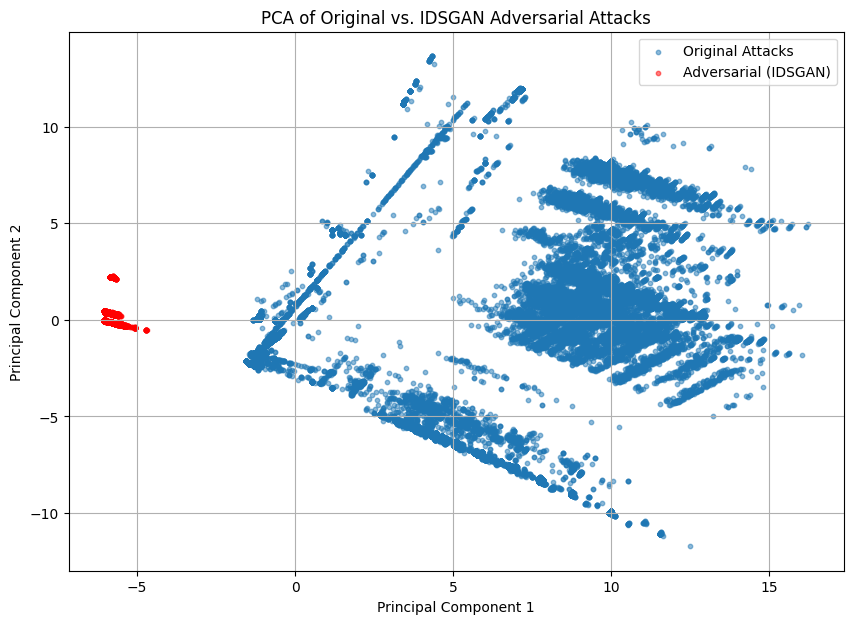

In [23]:
# --- Visualize the feature shifts using PCA ---

print("\n🎨 Visualizing feature space with PCA...")
pca = PCA(n_components=2)
# Combine original malicious and adversarial samples for PCA fitting
combined_samples = np.vstack([X_test_malicious_np, adv_samples_idsgan])
reduced_samples = pca.fit_transform(combined_samples)

# Separate the reduced data back into original and adversarial
num_original = len(X_test_malicious_np)
reduced_original = reduced_samples[:num_original]
reduced_adversarial = reduced_samples[num_original:]

# Plot the results
plt.figure(figsize=(10, 7))
plt.scatter(reduced_original[:, 0], reduced_original[:, 1], label='Original Attacks', alpha=0.5, s=10)
plt.scatter(reduced_adversarial[:, 0], reduced_adversarial[:, 1], label='Adversarial (IDSGAN)', alpha=0.5, s=10, c='red')
plt.title('PCA of Original vs. IDSGAN Adversarial Attacks')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend()
plt.grid(True)
plt.show()

### 4. Train and Evaluate AdvGAN

Finally, we will implement our second attack strategy using **AdvGAN**. Unlike IDSGAN, which generates an entirely new sample, AdvGAN's generator learns to produce a subtle **perturbation vector** (`Δx`) that is added to the original malicious sample.

Because our target IDS is already a PyTorch model (`KDDNet`), we can perform a **white-box** attack. This means the generator can get direct gradient feedback from the target IDS, which typically makes the attack more efficient and effective.

#### 4.1 Defining the AdvGAN Models

We need to define a new generator that outputs a perturbation and a standard discriminator to enforce realism.

-   **AdvGAN_Generator:** This generator takes a malicious sample `x` as input and outputs a perturbation `Δx`. The final adversarial sample is `x + Δx`. We multiply the perturbation by a small constant (e.g., 0.1) to keep the changes subtle. The mask ensures we only modify mutable features.
-   **AdvGAN_Discriminator:** This is a standard GAN discriminator. Its job is to distinguish between real, benign traffic and the generator's "fake" adversarial traffic. This forces the generator to create perturbations that are realistic and don't just look like random noise.

In [24]:
# --- 4a. Define AdvGAN Models ---

class AdvGAN_Generator(nn.Module):
    """
    AdvGAN Generator that learns to produce a small perturbation.
    """
    def __init__(self, input_dim):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(input_dim, 128), nn.ReLU(),
            nn.Linear(128, 128), nn.ReLU(),
            nn.Linear(128, input_dim), nn.Tanh() # Tanh outputs values in [-1, 1]
        )

    def forward(self, x, mask):
        # Generate a perturbation and scale it to keep it small
        perturbation = self.model(x) * 0.1
        # Apply the mask to the perturbation and add to the original input
        return x + perturbation * mask

class AdvGAN_Discriminator(nn.Module):
    """
    Standard discriminator to distinguish real (benign) vs fake (adversarial).
    """
    def __init__(self, input_dim):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(input_dim, 128), nn.ReLU(),
            nn.Linear(128, 1), nn.Sigmoid()
        )
    def forward(self, x):
        return self.model(x)

#### 4.2 Training the AdvGAN Framework

The training process for AdvGAN is more complex, as the generator must satisfy three competing objectives, which are combined into a single loss function:

-   **Adversarial Loss (`L_adv`):** Fool the target IDS.
-   **GAN Loss (`L_GAN`):** Fool the discriminator to ensure realism.
-   **Perturbation Loss (`L_pert`):** Keep the changes small and subtle.

We use `lambda` hyperparameters to balance the importance of these different losses.

In [25]:
# --- 4b. Train AdvGAN ---

# Initialize models, placing them on the selected device
generator_advgan = AdvGAN_Generator(input_dim).to(device)
discriminator_advgan = AdvGAN_Discriminator(input_dim).to(device)

# Define the three distinct loss functions
loss_adv = nn.BCELoss()   # For fooling the target IDS
loss_gan = nn.BCELoss()   # For the realism game with the discriminator
loss_pert = nn.MSELoss()  # To keep the perturbation small

# Initialize optimizers
opt_g_advgan = optim.Adam(generator_advgan.parameters(), lr=0.001)
opt_d_advgan = optim.Adam(discriminator_advgan.parameters(), lr=0.001)

# Hyperparameters to weigh the different generator losses
lambda_adv = 1.0
lambda_pert = 0.1

print("\n🔥 Training AdvGAN...")
for epoch in range(10): # Using fewer epochs for demonstration
    for (malicious_batch,), (benign_batch,) in zip(malicious_loader, benign_loader):
        malicious_batch, benign_batch = malicious_batch.to(device), benign_batch.to(device)

        # --- Train Discriminator ---
        # The discriminator's job is to learn the difference between
        # real benign traffic and the generator's adversarial traffic.
        opt_d_advgan.zero_grad()
        
        # Train with real (benign) samples, labeled as 1 (real)
        d_real_preds = discriminator_advgan(benign_batch)
        d_loss_real = loss_gan(d_real_preds, torch.ones_like(d_real_preds))
        
        # Train with fake (adversarial) samples, labeled as 0 (fake)
        adv_samples = generator_advgan(malicious_batch, mask_tensor).detach()
        d_fake_preds = discriminator_advgan(adv_samples)
        d_loss_fake = loss_gan(d_fake_preds, torch.zeros_like(d_fake_preds))
        
        d_loss = (d_loss_real + d_loss_fake) / 2
        d_loss.backward()
        opt_d_advgan.step()

        # --- Train Generator ---
        # The generator must satisfy three goals simultaneously.
        opt_g_advgan.zero_grad()
        adv_samples_for_g = generator_advgan(malicious_batch, mask_tensor)
        
        # Goal 1: Fool the target IDS (Adversarial Loss)
        # We get feedback directly from our white-box PyTorch IDS.
        target_ids_pytorch.eval() # Target model is only for inference
        target_preds = target_ids_pytorch(adv_samples_for_g)
        g_loss_adv = loss_adv(target_preds, torch.zeros_like(target_preds)) # We want the IDS to predict 0 (Benign)

        # Goal 2: Fool the discriminator (GAN/Realism Loss)
        # We want the discriminator to think our samples are real (label 1).
        disc_preds = discriminator_advgan(adv_samples_for_g)
        g_loss_gan = loss_gan(disc_preds, torch.ones_like(disc_preds))

        # Goal 3: Keep the perturbation small (Perturbation Loss)
        # We penalize large differences between the original and adversarial sample.
        g_loss_pert = loss_pert(adv_samples_for_g, malicious_batch)
        
        # Combine the three losses into a single objective for the generator
        g_loss = g_loss_gan + lambda_adv * g_loss_adv + lambda_pert * g_loss_pert
        g_loss.backward()
        opt_g_advgan.step()
        
    print(f"Epoch {epoch+1}: D Loss={d_loss.item():.4f}, G Loss={g_loss.item():.4f}")


🔥 Training AdvGAN...
Epoch 1: D Loss=0.0751, G Loss=8.8564
Epoch 2: D Loss=0.0078, G Loss=11.0020
Epoch 3: D Loss=0.0283, G Loss=10.6212
Epoch 4: D Loss=0.0082, G Loss=12.3991
Epoch 5: D Loss=0.0069, G Loss=15.5997
Epoch 6: D Loss=0.0063, G Loss=14.6416
Epoch 7: D Loss=0.0254, G Loss=10.8909
Epoch 8: D Loss=0.0062, G Loss=15.5878
Epoch 9: D Loss=0.0008, G Loss=15.8020
Epoch 10: D Loss=0.0004, G Loss=18.2550


#### 4.3 Evaluating AdvGAN's Evasion Effectiveness
Finally, we use the trained AdvGAN generator to craft adversarial examples from our test set of malicious traffic and measure how effectively they evade the target IDS.

In [27]:
# --- 4c. Evaluate AdvGAN Evasion ---

print("\n📊 AdvGAN Evasion Results:")
generator_advgan.eval() # Set the generator to evaluation mode

X_test_malicious = torch.tensor(X_test[y_test == 1], dtype=torch.float32).to(device)


# Generate adversarial samples for the malicious part of the test set
with torch.no_grad():
    adv_samples_advgan_tensor = generator_advgan(X_test_malicious, mask_tensor)
    
    # Get the final predictions from our target IDS
    adv_preds_advgan_probs = target_ids_pytorch(adv_samples_advgan_tensor)
    adv_preds_advgan = (adv_preds_advgan_probs.squeeze() > 0.5).cpu().numpy()

# Calculate the detection rate on the new adversarial samples
det_rate_adv_advgan = np.mean(adv_preds_advgan == 1)

print(f"Detection Rate on Original Attacks: {det_rate_orig:.2%}")
print(f"Detection Rate on AdvGAN Adversarial Attacks: {det_rate_adv_advgan:.2%}")


📊 AdvGAN Evasion Results:
Detection Rate on Original Attacks: 97.08%
Detection Rate on AdvGAN Adversarial Attacks: 38.81%


#### 3.5 Visualization of AdvGAN Evasion
To understand how AdvGAN modified the attack samples, we can use Principal Component Analysis (PCA) to reduce the high-dimensional feature space to just two dimensions. This allows us to plot the original and adversarial samples and see if the generator has learned to shift the attack data into a new cluster to achieve evasion.


🎨 Visualizing feature space with PCA for AdvGAN...


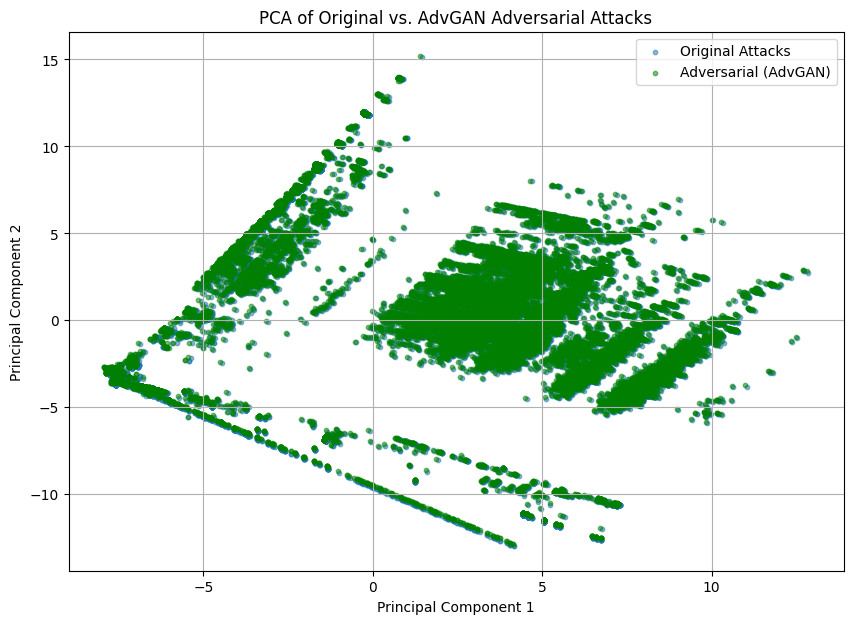

In [28]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# --- Visualize the feature shifts using PCA ---

print("\n🎨 Visualizing feature space with PCA for AdvGAN...")

# --- Prepare the data for visualization ---
# 1. Get the original malicious samples as a NumPy array
X_test_malicious_np = X_test[y_test == 1]

# 2. Get the adversarial samples as a NumPy array
# We already generated 'adv_samples_advgan_tensor' in the previous evaluation cell.
# We just need to ensure it's on the CPU and converted to NumPy.
adv_samples_advgan = adv_samples_advgan_tensor.cpu().numpy()

# --- Apply PCA ---
pca_advgan = PCA(n_components=2)
# Combine original malicious and new adversarial samples for PCA fitting
combined_samples_advgan = np.vstack([X_test_malicious_np, adv_samples_advgan])
reduced_samples_advgan = pca_advgan.fit_transform(combined_samples_advgan)

# Separate the reduced data back into original and adversarial
num_original = len(X_test_malicious_np)
reduced_original = reduced_samples_advgan[:num_original]
reduced_adversarial = reduced_samples_advgan[num_original:]

# --- Plot the results ---
plt.figure(figsize=(10, 7))
plt.scatter(reduced_original[:, 0], reduced_original[:, 1], label='Original Attacks', alpha=0.5, s=10)
plt.scatter(reduced_adversarial[:, 0], reduced_adversarial[:, 1], label='Adversarial (AdvGAN)', alpha=0.5, s=10, c='green')
plt.title('PCA of Original vs. AdvGAN Adversarial Attacks')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend()
plt.grid(True)
plt.show()

**Discussion:**
This model represents a standard supervised ML-IDS.
Next, we’ll attempt to fool this classifier by generating adversarial samples.

### Exercises – GAN-Based Evasion

**Exercise 1: Attack Success vs. Perturbation Strength**  
Adjust the generator’s learning rate or noise level and observe how it affects evasion success.

**Exercise 2: Constrained GANs**  
Implement feature constraints to ensure generated samples remain valid (e.g., no negative packet counts).

**Exercise 3: Compare Models**  
Train alternative IDS classifiers (Random Forest, CNN) and compare adversarial robustness.

**Exercise 4: Evaluate Transferability**  
Test whether adversarial samples crafted for one IDS (e.g., MLP) can fool another (e.g., SVM).


## Conclusion
In this tutorial, we replicated the core idea from **Zolbayar et al. (2021):**  
> GANs can be used to craft adversarial network traffic capable of evading ML-based IDS.

By training a generator to produce **constrained adversarial features**, we demonstrated:

- IDS models are **vulnerable to subtle perturbations**.  
- **Adversarial samples** can significantly reduce detection rates.  
- **Defensive retraining** and **ensemble methods** are necessary to mitigate such attacks.

This highlights the **arms race** between attackers and defenders in the **ML-driven cybersecurity domain**.


---

[![Star our repository](https://img.shields.io/static/v1.svg?logo=star&label=⭐&message=Star%20Our%20Repository&color=yellow)](https://github.com/clandolt/mlcysec_notebooks/)  If you found this tutorial helpful, please **⭐ star our repository** to show your support.   
[![Ask questions](https://img.shields.io/static/v1.svg?logo=star&label=❔&message=Ask%20Questions&color=9cf)](https://github.com/clandolt/mlcysec_notebooks/issues)  For any **questions**, **typos**, or **bugs**, kindly open an issue on GitHub — we appreciate your feedback!

---